In [1]:
import numpy as np
import matplotlib.pylab as plt
import sys
sys.path.append("..")

### 2D nodal --> modal

In [2]:
### test function 
def exact_bump2d(x, y):
    r2 = x**2 + y**2
    return np.exp(-5 * r2) * (1 + 0.5*x + 0.3*y)


def exact_poly2d_scaled(x, y, degree=4, xlim=(-1,1), ylim=(-1,1)):
    x = np.asarray(x)
    y = np.asarray(y)

    # map to [-1,1]
    xhat = 2*(x - xlim[0])/(xlim[1] - xlim[0]) - 1
    yhat = 2*(y - ylim[0])/(ylim[1] - ylim[0]) - 1

    poly = 0.1 * np.ones_like(xhat)

    if degree >= 1:
        poly += 0.3*xhat - 0.4*yhat
    if degree >= 2:
        poly += 0.5*xhat**2 + 0.2*xhat*yhat - 0.6*yhat**2
    if degree >= 3:
        poly += -0.7*xhat**3 + 0.4*xhat**2*yhat - 0.3*xhat*yhat**2 + 0.2*yhat**3
    if degree >= 4:
        poly += 0.25*xhat**4 - 0.35*xhat**3*yhat + 0.15*xhat**2*yhat**2 + 0.1*xhat*yhat**3 - 0.2*yhat**4
    if degree >= 5:
        poly += -0.1*xhat**5 + 0.08*xhat**4*yhat - 0.06*xhat**3*yhat**2 + 0.04*xhat**2*yhat**3 - 0.02*xhat*yhat**4 + 0.05*yhat**5

    return poly



def add_noise(exact_data, hx, hy, p, sigma_scale=1.0, seed=62):
    """
    Add noise to the exact function exact_func.
    hx - element spacing x
    hy - element spacing y
    p - DG polynomial basis degree
    basic: noise of level h**(p+1), h = sqrt(hx^2 + hy^2), characteristic length of mesh
    """
    rng = np.random.default_rng(seed)
    
    h = np.sqrt(hx**2 + hy**2)
    pw = p+1
    sigma = h ** pw
    
    noise = rng.standard_normal(*exact_data.shape) * sigma * sigma_scale
    
    print(f"[noise] h={h:.3e}, sigma={sigma:.3e} (h^{pw})")
    rel_noise = np.linalg.norm(noise) / np.linalg.norm(exact_data)
    print(f"[rel.noise] rel_noise={rel_noise:.3e}")
    
    return exact_data + noise


roundtrip max error = 8.881784197001252e-16
roundtrip rel error = 3.6508604221018937e-16


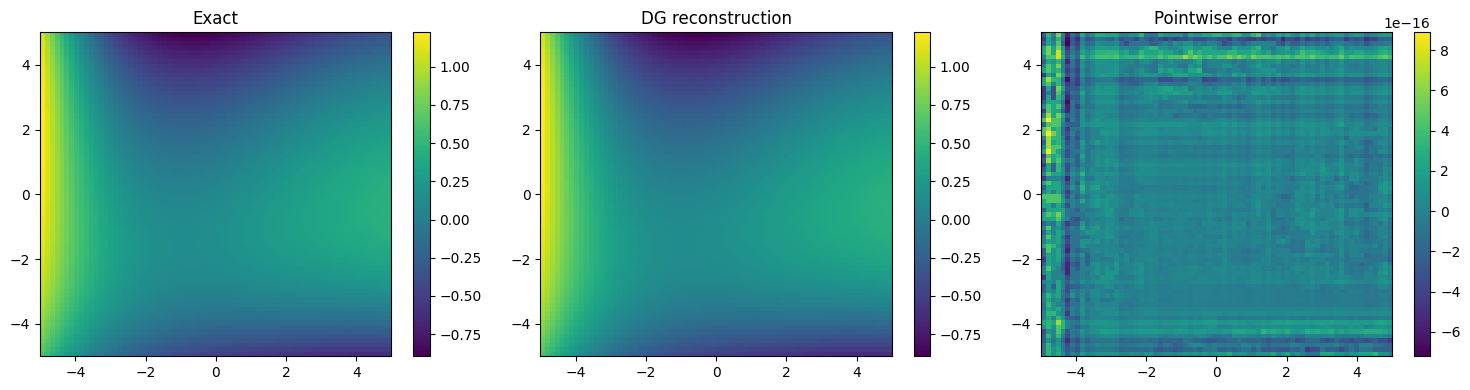

In [3]:
from src.dg_nodal_transform import nodal_image_to_dg
from src.dg_utils import eval_dg_modal, build_image_grid
import numpy as np

### setup
xmin, xmax = -5, 5
ymin, ymax = -5, 5
xlim = (xmin, xmax)
ylim = (ymin, ymax)

### DG stuff
Kx, Ky = 24, 24
p = 2
Nx, Ny = Kx * (p + 1), Ky * (p + 1)

xgrid, ygrid, dx, dy = build_image_grid(
    DOF_x=Nx, DOF_y=Ny,
    xlim=(xmin, xmax), ylim=(ymin, ymax)
)

X, Y = np.meshgrid(xgrid, ygrid, indexing="xy")

exact_poly_deg = p+2        # needs to be p for machine precision for DG

# exact_data = exact_poly2d_compact(
#     x=X, y=Y,
#     xlim=(xmin, xmax), ylim=(ymin, ymax),
#     degree=exact_poly_deg
# )

exact_data = exact_poly2d_scaled(x=X, y=Y, degree=exact_poly_deg, xlim=xlim, ylim=ylim)

dg = nodal_image_to_dg(
    recon=exact_data,
    xlim=(xmin, xmax), ylim=(ymin, ymax),
    deg=p
)

# make sure grids align
assert np.allclose(dg["xgrid"], xgrid)
assert np.allclose(dg["ygrid"], ygrid)
assert np.isclose(dg["dx"], dx)
assert np.isclose(dg["dy"], dy)

Urec = eval_dg_modal(dg, X, Y)

err_max = np.max(np.abs(Urec - exact_data))
err_rel = np.linalg.norm(Urec - exact_data) / np.linalg.norm(exact_data)

print("roundtrip max error =", err_max)
print("roundtrip rel error =", err_rel)


# error
err = Urec - exact_data

fig, axs = plt.subplots(1, 3, figsize=(15, 4))

# --- Exact ---
im0 = axs[0].imshow(
    exact_data,
    origin="lower",
    extent=[xmin, xmax, ymin, ymax],
    aspect="auto"
)
axs[0].set_title("Exact")
plt.colorbar(im0, ax=axs[0])

# --- DG reconstruction ---
im1 = axs[1].imshow(
    Urec,
    origin="lower",
    extent=[xmin, xmax, ymin, ymax],
    aspect="auto"
)
axs[1].set_title("DG reconstruction")
plt.colorbar(im1, ax=axs[1])

# --- Error ---
im2 = axs[2].imshow(
    err,
    origin="lower",
    extent=[xmin, xmax, ymin, ymax],
    aspect="auto"
)
axs[2].set_title("Pointwise error")
plt.colorbar(im2, ax=axs[2])

plt.tight_layout()
plt.show()

roundtrip max error = 3.981564836719187e-07
roundtrip rel error = 1.2402081274626608e-06


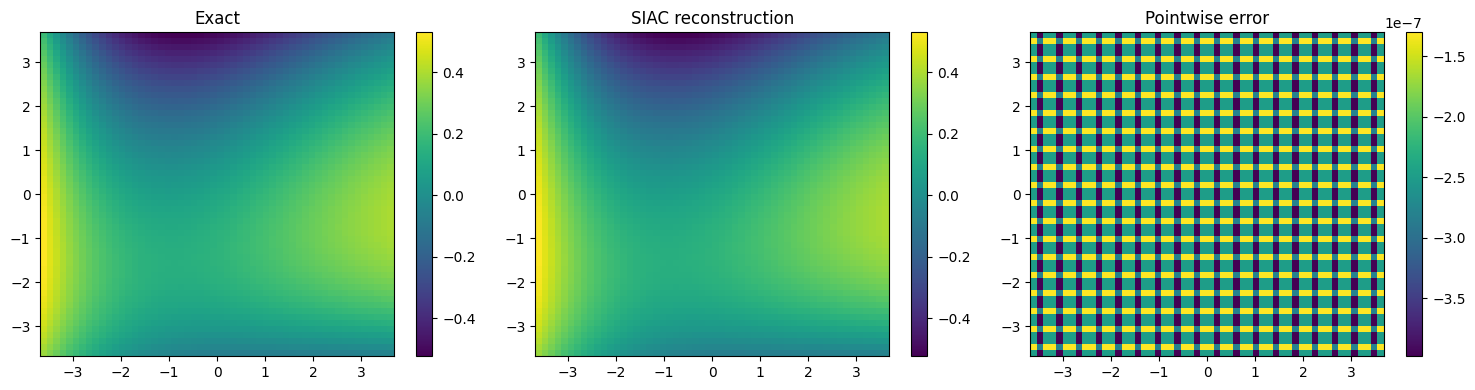

In [4]:
from src.siac_modal import apply_siac_modal_dg
### Apply SIAC an check machine precision

moments = 2
BSorder = 1

Usiac = apply_siac_modal_dg(dg=dg, moments=moments, BSorder=BSorder)

# extract interior only
halfker = int(np.ceil((moments + BSorder)/2)) + 1
trim = halfker * (p + 1)
sl_y = slice(trim, -trim)
sl_x = slice(trim, -trim)

Xp = X[sl_y, sl_x]
Yp = Y[sl_y, sl_x]

exact_datap = exact_data[sl_y, sl_x]
Usiacp = Usiac[sl_y, sl_x]

err_max = np.max(np.abs(Usiacp - exact_datap))
err_rel = np.linalg.norm(Usiacp - exact_datap) / np.linalg.norm(exact_datap)

print("roundtrip max error =", err_max)
print("roundtrip rel error =", err_rel)

# error internal
errp = Usiacp - exact_datap

fig, axs = plt.subplots(1, 3, figsize=(15, 4))

xminp, xmaxp = Xp.min(), Xp.max()
yminp, ymaxp = Yp.min(), Yp.max()

# --- Exact ---
im0 = axs[0].imshow(
    exact_datap,
    origin="lower",
    extent=[xminp, xmaxp, yminp, ymaxp],
    aspect="auto"
)
axs[0].set_title("Exact")
plt.colorbar(im0, ax=axs[0])

# --- DG reconstruction ---
im1 = axs[1].imshow(
    Usiacp,
    origin="lower",
    extent=[xminp, xmaxp, yminp, ymaxp],
    aspect="auto"
)
axs[1].set_title("SIAC reconstruction")
plt.colorbar(im1, ax=axs[1])

# --- Error ---
im2 = axs[2].imshow(
    errp,
    origin="lower",
    extent=[xminp, xmaxp, yminp, ymaxp],
    aspect="auto"
)
axs[2].set_title("Pointwise error")
plt.colorbar(im2, ax=axs[2])

plt.tight_layout()
plt.show()

### Pointwise error on fine grid

In [12]:
import numpy as np

from src.siac_modal import (
    siac_cgam,
    grab_integrals,
    pad_modal_coeffs_2d,
)

def eval_siac_2d_on_grid(dg, X, Y, moments=None, BSorder=None, fill_value=0.0):
    """
    Evaluate SIAC-postprocessed DG field at arbitrary physical points (X,Y).

    Assumes:
        coeffs[ey, ex, mode_y, mode_x]

    Parameters
    ----------
    dg : dict
        DG representation.
    X, Y : array_like
        Physical evaluation points. Can be meshgrid arrays or broadcastable arrays.
    moments : int or None
        Number of reproduced moments. Default: 2*p.
    BSorder : int or None
        B-spline order. Default: p+1.
    fill_value : float
        Value outside the physical domain.

    Returns
    -------
    U : ndarray
        SIAC-evaluated field with shape broadcast(X, Y).
    """
    mesh = dg["mesh"]
    coeffs = dg["coeffs"]

    p = mesh["p"]
    order = mesh["order"]
    Kx = mesh["Kx"]
    Ky = mesh["Ky"]
    x_edges = mesh["x_edges"]
    y_edges = mesh["y_edges"]
    xmin, xmax, ymin, ymax = mesh["domain"]

    if moments is None:
        moments = 2 * p
    if BSorder is None:
        BSorder = p + 1

    # Broadcast evaluation points
    X = np.asarray(X, dtype=float)
    Y = np.asarray(Y, dtype=float)
    Xb, Yb = np.broadcast_arrays(X, Y)

    Xf = Xb.ravel()
    Yf = Yb.ravel()
    Uf = np.full(Xf.shape, fill_value, dtype=float)

    # Domain mask
    inside = (Xf >= xmin) & (Xf <= xmax) & (Yf >= ymin) & (Yf <= ymax)
    if not np.any(inside):
        return Uf.reshape(Xb.shape)

    Xi = Xf[inside]
    Yi = Yf[inside]

    # Element indices
    ex = np.searchsorted(x_edges, Xi, side="right") - 1
    ey = np.searchsorted(y_edges, Yi, side="right") - 1
    ex = np.clip(ex, 0, Kx - 1)
    ey = np.clip(ey, 0, Ky - 1)

    # Element bounds
    x0 = x_edges[ex]
    x1 = x_edges[ex + 1]
    y0 = y_edges[ey]
    y1 = y_edges[ey + 1]

    # Local coordinates in [-1,1]
    r = 2.0 * (Xi - x0) / (x1 - x0) - 1.0
    s = 2.0 * (Yi - y0) / (y1 - y0) - 1.0
    r = np.clip(r, -1.0, 1.0)
    s = np.clip(s, -1.0, 1.0)

    # SIAC kernel support info
    BSknots = np.linspace(-BSorder / 2, BSorder / 2, BSorder + 1)
    BSsupport = np.array([np.floor(BSknots[0]), np.ceil(BSknots[-1])], dtype=int)
    BSlen = int(BSsupport[1] - BSsupport[0] + 1)

    cgam = siac_cgam(moments, BSorder)

    kernellength = int(2 * np.ceil((moments + BSorder) / 2) + 1)
    halfker = int(np.ceil((moments + BSorder) / 2))

    # Pad modal coefficients in element space
    pad = halfker + 1
    coeffs_pad = pad_modal_coeffs_2d(coeffs, pad_x=pad, pad_y=pad)

    # Precompute SIAC 1D matrices for unique local coordinates
    r_unique, r_inv = np.unique(r, return_inverse=True)
    s_unique, s_inv = np.unique(s, return_inverse=True)

    BSInt_r = grab_integrals(
        eval_nodes=r_unique,
        p=p,
        BSorder=BSorder,
        BSsupport=BSsupport
    )  # shape (order, BSlen, nr)

    BSInt_s = grab_integrals(
        eval_nodes=s_unique,
        p=p,
        BSorder=BSorder,
        BSsupport=BSsupport
    )  # shape (order, BSlen, ns)

    SIAC_r = np.zeros((order, kernellength, len(r_unique)), dtype=float)
    SIAC_s = np.zeros((order, kernellength, len(s_unique)), dtype=float)

    for k in range(len(r_unique)):
        for igam in range(moments + 1):
            SIAC_r[:, igam:igam + BSlen, k] += cgam[igam] * BSInt_r[:, :, k]

    for k in range(len(s_unique)):
        for igam in range(moments + 1):
            SIAC_s[:, igam:igam + BSlen, k] += cgam[igam] * BSInt_s[:, :, k]

    # Evaluate pointwise
    out_inside = np.zeros_like(Xi)

    for q in range(Xi.size):
        cx = ex[q] + pad
        cy = ey[q] + pad

        block = coeffs_pad[
            cy - halfker : cy + halfker + 1,
            cx - halfker : cx + halfker + 1,
            :,
            :
        ]  # shape (kernellength, kernellength, mode_y, mode_x)

        Sy = SIAC_s[:, :, s_inv[q]]   # (mode_y, stencil_y)
        Sx = SIAC_r[:, :, r_inv[q]]   # (mode_x, stencil_x)

        # coeff convention: block[ry, rx, mode_y, mode_x]
        out_inside[q] = np.einsum("mr,ns,rsmn->", Sy, Sx, block)

    Uf[inside] = out_inside
    return Uf.reshape(Xb.shape)

In [13]:
### Helper
import numpy as np
import matplotlib.pyplot as plt
from src.metrics import rel_l2_err

def plot_finegrid_dg_siac_interior(
    X_fine,
    Y_fine,
    U_exact_fine,
    U_dg_fine,
    U_siac_fine,
    mesh,
    moments,
    BSorder,
    figsize=(14, 8),
    cmap_sol="viridis",
    cmap_err="seismic",
):
    """
    Plot exact, DG, and SIAC solutions on a fine grid, restricted to the SIAC-valid interior,
    together with DG and SIAC pointwise errors.

    Layout:
        [0,0] exact
        [0,1] DG
        [0,2] SIAC
        [1,0] empty
        [1,1] DG pointwise error
        [1,2] SIAC pointwise error

    Also prints relative L2 errors on the interior only.

    Parameters
    ----------
    X_fine, Y_fine : ndarray
        Fine-grid physical coordinates.
    U_exact_fine, U_dg_fine, U_siac_fine : ndarray
        Exact, DG, and SIAC values on the fine grid.
    mesh : dict
        DG mesh dictionary with keys "domain", "hx", "hy".
    moments : int
        SIAC reproduction moments used.
    BSorder : int
        SIAC B-spline order used.
    figsize : tuple
        Matplotlib figure size.
    cmap_sol : str
        Colormap for solution plots.
    cmap_err : str
        Colormap for error plots.

    Returns
    -------
    fig, axs, results : tuple
        Matplotlib figure/axes and a dictionary with errors and mask.
    """
    xmin, xmax, ymin, ymax = mesh["domain"]
    hx = mesh["hx"]
    hy = mesh["hy"]

    halfker = int(np.ceil((moments + BSorder) / 2))

    # Interior in physical coordinates
    crop_phys_x = halfker * hx
    crop_phys_y = halfker * hy

    mask_int = (
        (X_fine >= xmin + crop_phys_x) & (X_fine <= xmax - crop_phys_x) &
        (Y_fine >= ymin + crop_phys_y) & (Y_fine <= ymax - crop_phys_y)
    )

    # Errors
    err_dg = U_dg_fine - U_exact_fine
    err_siac = U_siac_fine - U_exact_fine

    # Relative L2 errors on the interior only
    dg_rel_l2 = rel_l2_err(U_dg_fine[mask_int], U_exact_fine[mask_int])
    siac_rel_l2 = rel_l2_err(U_siac_fine[mask_int], U_exact_fine[mask_int])

    print(f"[interior] DG   rel L2 error  = {dg_rel_l2:.6e}")
    print(f"[interior] SIAC rel L2 error  = {siac_rel_l2:.6e}")

    # Mask outside interior for plotting
    U_exact_plot = np.where(mask_int, U_exact_fine, np.nan)
    U_dg_plot    = np.where(mask_int, U_dg_fine,    np.nan)
    U_siac_plot  = np.where(mask_int, U_siac_fine,  np.nan)
    err_dg_plot  = np.where(mask_int, err_dg,       np.nan)
    err_siac_plot= np.where(mask_int, err_siac,     np.nan)

    # Shared color scale for solutions
    sol_vmin = np.nanmin([U_exact_plot, U_dg_plot, U_siac_plot])
    sol_vmax = np.nanmax([U_exact_plot, U_dg_plot, U_siac_plot])

    # Symmetric color scale for errors
    errmax = max(
        np.nanmax(np.abs(err_dg_plot)),
        np.nanmax(np.abs(err_siac_plot))
    )
    if errmax == 0:
        errmax = 1.0

    fig, axs = plt.subplots(2, 3, figsize=figsize, constrained_layout=True)

    extent = [xmin, xmax, ymin, ymax]

    # Row 0
    im00 = axs[0, 0].imshow(
        U_exact_plot,
        origin="lower",
        extent=extent,
        aspect="auto",
        cmap=cmap_sol,
        vmin=sol_vmin,
        vmax=sol_vmax,
    )
    axs[0, 0].set_title("Exact (fine grid, interior)")
    plt.colorbar(im00, ax=axs[0, 0])

    im01 = axs[0, 1].imshow(
        U_dg_plot,
        origin="lower",
        extent=extent,
        aspect="auto",
        cmap=cmap_sol,
        vmin=sol_vmin,
        vmax=sol_vmax,
    )
    axs[0, 1].set_title("DG eval (fine grid, interior)")
    plt.colorbar(im01, ax=axs[0, 1])

    im02 = axs[0, 2].imshow(
        U_siac_plot,
        origin="lower",
        extent=extent,
        aspect="auto",
        cmap=cmap_sol,
        vmin=sol_vmin,
        vmax=sol_vmax,
    )
    axs[0, 2].set_title("SIAC eval (fine grid, interior)")
    plt.colorbar(im02, ax=axs[0, 2])

    # Row 1
    axs[1, 0].axis("off")

    im11 = axs[1, 1].imshow(
        err_dg_plot,
        origin="lower",
        extent=extent,
        aspect="auto",
        cmap=cmap_err,
        vmin=-errmax,
        vmax=errmax,
    )
    axs[1, 1].set_title(f"DG pointwise error\nrel L2 = {dg_rel_l2:.3e}")
    plt.colorbar(im11, ax=axs[1, 1])

    im12 = axs[1, 2].imshow(
        err_siac_plot,
        origin="lower",
        extent=extent,
        aspect="auto",
        cmap=cmap_err,
        vmin=-errmax,
        vmax=errmax,
    )
    axs[1, 2].set_title(f"SIAC pointwise error\nrel L2 = {siac_rel_l2:.3e}")
    plt.colorbar(im12, ax=axs[1, 2])

    for ax in axs.ravel():
        if ax is not axs[1, 0]:
            ax.set_xlabel("x")
            ax.set_ylabel("y")

    results = {
        "mask_int": mask_int,
        "dg_rel_l2": dg_rel_l2,
        "siac_rel_l2": siac_rel_l2,
        "err_dg": err_dg,
        "err_siac": err_siac,
        "crop_phys_x": crop_phys_x,
        "crop_phys_y": crop_phys_y,
        "halfker": halfker,
    }

    return fig, axs, results

In [14]:
### setup
xmin, xmax = -5, 5
ymin, ymax = -5, 5


def exact_func_sincos(x, y, domain=(-1,-1,1,1)):
    xmin, ymin, xmax, ymax = domain
    # map coordinates
    xhat = (x-xmin) / (xmax-xmin)
    yhat = (y-ymin) / (ymax-ymin)
    
    return np.sin(2*np.pi*xhat)*np.cos(2*np.pi*yhat) + 0.2*np.sin(4*np.pi*xhat)*np.sin(np.pi*yhat)


### DG stuff
Kx, Ky = 24, 24
p = 2
Nx, Ny = Kx * (p + 1), Ky * (p + 1)

xgrid, ygrid, dx, dy = build_image_grid(
    DOF_x=Nx, DOF_y=Ny,
    xlim=(xmin, xmax), ylim=(ymin, ymax)
)

X, Y = np.meshgrid(xgrid, ygrid, indexing="xy")

# fine grid setup for intra-element evaluation
xgrid_fine, ygrid_fine, dx_fine, dy_fine = build_image_grid(
    DOF_x=8*Nx, DOF_y=8*Ny,
    xlim=(xmin, xmax), ylim=(ymin, ymax)
)
X_fine, Y_fine = np.meshgrid(xgrid_fine, ygrid_fine, indexing="xy")

### DG stuff
Kx, Ky = 24, 24
p = 2
Nx, Ny = Kx * (p + 1), Ky * (p + 1)

xgrid, ygrid, dx, dy = build_image_grid(
    DOF_x=Nx, DOF_y=Ny,
    xlim=(xmin, xmax), ylim=(ymin, ymax)
)

X, Y = np.meshgrid(xgrid, ygrid, indexing="xy")

domain = (xmin, ymin, xmax, ymax)
U_exact = exact_func_sincos(X, Y, domain)
dg = nodal_image_to_dg(
    recon=U_exact,
    xlim=(xmin, xmax), ylim=(ymin, ymax),
    deg=p
)

mesh = dg["mesh"]

U_dg_fine = eval_dg_modal(dg, X_fine, Y_fine)
U_exact_fine = exact_func_sincos(X_fine, Y_fine, domain)

# SIAC
moments = 2 * p
BSorder = p + 1

U_siac_fine = eval_siac_2d_on_grid(dg=dg, X=X_fine, Y=Y_fine, 
                                   moments=moments, BSorder=BSorder)



[interior] DG   rel L2 error  = 1.624947e-04
[interior] SIAC rel L2 error  = 7.048795e-06


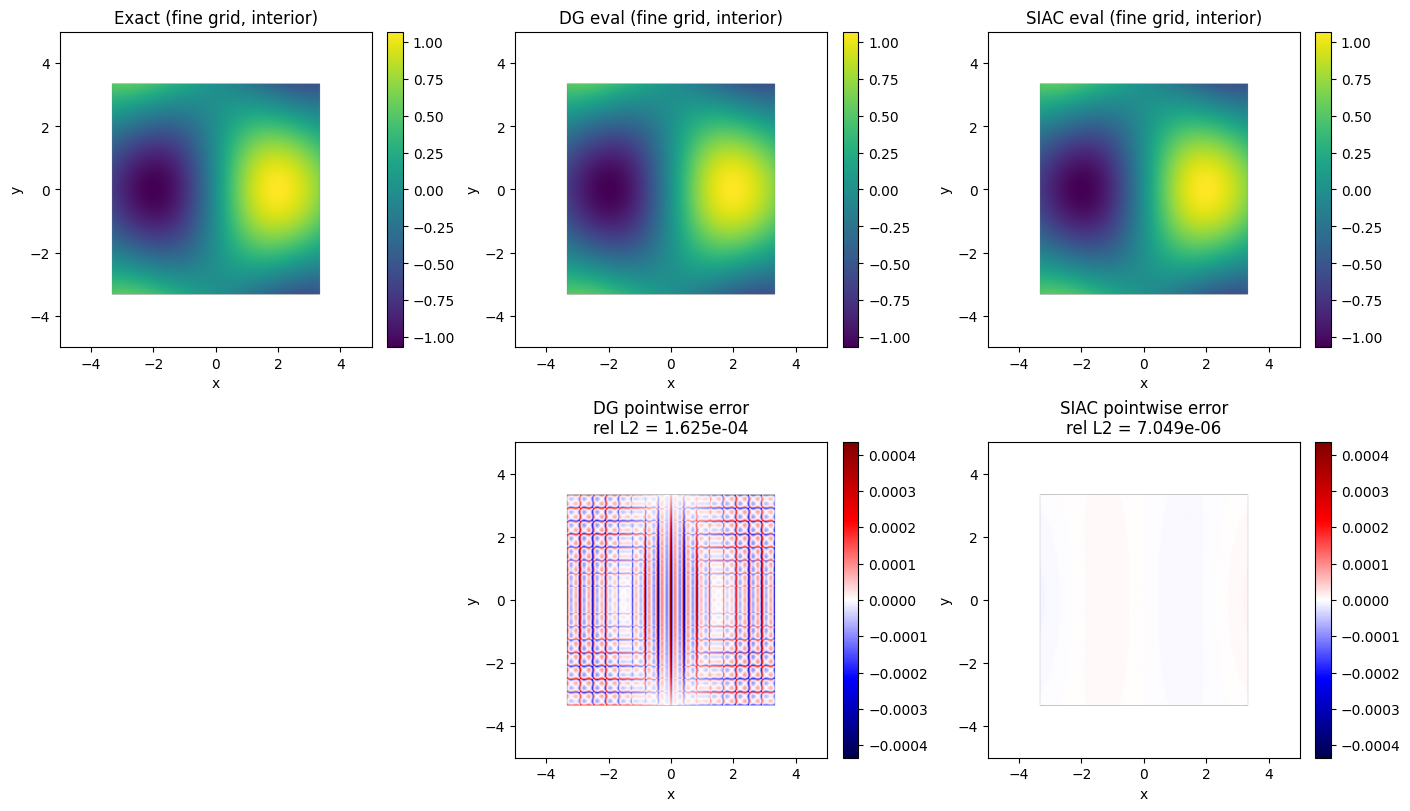

In [15]:

fig, axs, results = plot_finegrid_dg_siac_interior(
    X_fine=X_fine,
    Y_fine=Y_fine,
    U_exact_fine=U_exact_fine,
    U_dg_fine=U_dg_fine,
    U_siac_fine=U_siac_fine,
    mesh=dg["mesh"],
    moments=moments,
    BSorder=BSorder,
)
plt.show()

In [16]:

def l2_err(x: np.ndarray, xtrue: np.ndarray):
    return np.linalg.norm(x - xtrue)


def run_dg_siac_convergence_2d(
    exact_func,
    K_values,
    p,
    xlim=(-1.0, 1.0),
    ylim=(-1.0, 1.0),
    fine_DOF_x=801,
    fine_DOF_y=801,
    moments=None,
    BSorder=None,
    use_relative=True,
    add_noise=False,
    noise_fn=None,
):
    """
    Run a 2D DG vs SIAC convergence study on a sequence of meshes.

    Parameters
    ----------
    exact_func : callable
        Function exact_func(X, Y) returning exact values on arrays.
    K_values : iterable[int] or iterable[tuple[int,int]]
        Mesh sizes. If int, uses Kx=Ky=K. If tuple, uses (Kx,Ky).
    p : int
        DG polynomial degree.
    xlim, ylim : tuple
        Physical domain bounds.
    fine_DOF_x, fine_DOF_y : int
        Resolution of fixed fine evaluation grid.
    moments : int or None
        SIAC moments. Default 2*p.
    BSorder : int or None
        SIAC B-spline order. Default p+1.
    use_relative : bool
        If True compute relative L2 errors, else absolute L2.
    add_noise : bool
        Whether to perturb nodal sampled data before nodal->modal transform.
    noise_fn : callable or None
        Optional function noisy_data = noise_fn(data, hx, hy, p).
        Used only if add_noise=True.

    Returns
    -------
    results : list[dict]
        One dictionary per mesh with errors and metadata.
    """

    if moments is None:
        moments = 2 * p
    if BSorder is None:
        BSorder = p + 1

    xmin, xmax = xlim
    ymin, ymax = ylim

    # Fixed fine grid for comparison
    xgrid_fine, ygrid_fine, _, _ = build_image_grid(
        DOF_x=fine_DOF_x,
        DOF_y=fine_DOF_y,
        xlim=xlim,
        ylim=ylim,
    )
    X_fine, Y_fine = np.meshgrid(xgrid_fine, ygrid_fine, indexing="xy")
    U_exact_fine = exact_func(X_fine, Y_fine)

    results = []

    for K in K_values:
        Kx = K
        Ky = K

        order = p + 1
        Nx = Kx * order
        Ny = Ky * order

        # Original image/pixel-center grid
        xgrid, ygrid, dx, dy = build_image_grid(
            DOF_x=Nx,
            DOF_y=Ny,
            xlim=xlim,
            ylim=ylim,
        )
        X, Y = np.meshgrid(xgrid, ygrid, indexing="xy")

        # Sample exact data on original nodal/image grid
        exact_data = exact_func(X, Y)

        # Optional noise
        if add_noise:
            if noise_fn is None:
                raise ValueError("add_noise=True but no noise_fn was provided.")
            hx = (xmax - xmin) / Kx
            hy = (ymax - ymin) / Ky
            exact_data = noise_fn(exact_data, hx=hx, hy=hy, p=p)

        # Build DG representation
        dg = nodal_image_to_dg(
            recon=exact_data,
            xlim=xlim,
            ylim=ylim,
            deg=p,
        )

        # Evaluate DG and SIAC on same fine grid
        U_dg_fine = eval_dg_modal(dg, X_fine, Y_fine)

        U_siac_fine = eval_siac_2d_on_grid(
            dg, X_fine, Y_fine,
            moments=moments,
            BSorder=BSorder,
            fill_value=0.0,
        )

        # Interior mask based on SIAC stencil half-width
        halfker = int(np.ceil((moments + BSorder) / 2))
        hx = dg["mesh"]["hx"]
        hy = dg["mesh"]["hy"]

        crop_phys_x = halfker * hx
        crop_phys_y = halfker * hy

        mask_int = (
            (X_fine >= xmin + crop_phys_x) & (X_fine <= xmax - crop_phys_x) &
            (Y_fine >= ymin + crop_phys_y) & (Y_fine <= ymax - crop_phys_y)
        )

        Ue_int = U_exact_fine[mask_int]
        Udg_int = U_dg_fine[mask_int]
        Usiac_int = U_siac_fine[mask_int]
        
        dg_l2 = l2_err(Udg_int, Ue_int)
        dg_l2_rel = rel_l2_err(Udg_int, Ue_int)
        
        siac_l2 = l2_err(Usiac_int, Ue_int)
        siac_l2_rel = rel_l2_err(Usiac_int, Ue_int)
        
        h = np.sqrt(hx**2 + hy**2)
        
        results.append({
            "h": h,
            "p": p, 
            "dg_l2": dg_l2,
            "dg_l2_rel": dg_l2_rel,
            "siac_l2": siac_l2, 
            "siac_l2_rel": siac_l2_rel
        })

        print(
            f"K=({Kx},{Ky}), h={np.sqrt(hx**2 + hy**2):.3e}, "
            f"DG L2={dg_l2:.6e}, SIAC L2={siac_l2:.6e}, "
            f"DG L2={dg_l2:.6e}, SIAC L2={siac_l2:.6e}\n"
        )

    return results

### Convergence study

In [17]:
def add_noise2(exact_data, hx, hy, p, sigma_scale=1.0, seed=62):
    """
    Add noise to the exact function exact_func.
    hx - element spacing x
    hy - element spacing y
    p - DG polynomial basis degree
    basic: noise of level h**(p+1), h = sqrt(hx^2 + hy^2), characteristic length of mesh
    """
    rng = np.random.default_rng(seed)
    
    h = np.sqrt(hx**2 + hy**2)
    pw = p+1
    sigma = h ** pw
    
    noise = rng.standard_normal(*exact_data.shape) * sigma * sigma_scale
    
    return exact_data + noise


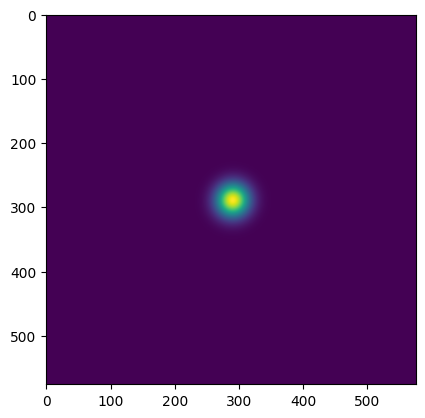

In [18]:
# Function exact_func(X, Y) returning exact values on arrays.
plt.imshow(exact_bump2d(X_fine, Y_fine))
plt.show()

In [19]:

K_values = 16 * 2**np.arange(5)

Kmax = K_values[-1]
nr_eval_points = 5*Kmax

# Dg stuff
p = 2

# SIAC stuff
moments = 2 * p
BSorder = p + 1

xmin, xmax = -5, 5
ymin, ymax = -5, 5

results = run_dg_siac_convergence_2d(
    exact_func=exact_bump2d,
    K_values=K_values,
    p=p,
    xlim=(xmin, xmax),
    ylim=(ymin, ymax),
    fine_DOF_x=nr_eval_points,
    fine_DOF_y=nr_eval_points,
    moments=moments,
    BSorder=BSorder,
    use_relative=True,
    add_noise=False, 
    noise_fn = add_noise2
)

KeyboardInterrupt: 